# Evaluating Variable Obfuscation on Perplexity and Self-preference in Code Review
<!-- 2026-08-22 -->

## Background

Language models are known to exhibit preference for their own model outputs while evaluating the quality of task completikon. This happens across [many different models](https://arxiv.org/abs/2506.02592), even when [objective criteria are given to inform judgment](https://arxiv.org/abs/2604.06996). [Self-refinement of LLM outputs](https://arxiv.org/abs/2402.11436) tends to amplify this self-preference bias. 

Some [work suggests](https://arxiv.org/abs/2410.21819v1) that lower perplexity from self-generated work may be a driver behind this self-preference. The perplexity of a given text to a model can be loosely understood to indicate how similar the text is to samples that the model saw during training. During language model training, high-perplexity tokens are used to update the weights to enable effective token prediction. Text generated by a given language model will naturally be lower-perplexity than text generated by a human or by a different language model. 

## AI Assisted Coding and Self-Preference

This self-preference presents an opportunity for improving AI-assisted coding. If a model generates, reviews, and refines its own output, the effects of self-preference may intefere with a model's ability to effectively complete coding tasks. In a [previous experiment](https://www.zacharyclement.com/posts/code_reviewing_performance), I saw clear self-preference effects resulting in lower recall rates of bugs detected by model self-generated outputs.

AI assisted coding is unique because is fairly easy to manipulate perplexity while retaining code functionality and correctness. Within a function, the spelling of local variable names and commented-out code can be changed while leaving core functionality (e.g. whether it completes a given task) intact. If self-preference can be manipulated by merely changing code perplexity, LLM-assisted coding harnesses can programmatically manipulate pieces of code that don't impact code logic to improve code review quality and self-improvement. 

## The current experiment

In this experiment, I will manipulate perplexity of given code outputs by generating high-perplexity strings from the hash of variable names and either appending those high-perplexity strings to the end of model outputs or replacing those high-perplexity strings. 

I will use an open-source language model (Qwen2.5-Coder-7B-Instruct) to validate that the hash-appending strategy actually increases code perplexity. Then, I will use both `gemini-3.5-flash-lite` and `gpt-5.6-luna` (which had high self-preference bias in our [previous experiment](https://www.zacharyclement.com/posts/code_reviewing_performance)) to evaluate whether increasing model perplexity reduces self-preference and makes a model more able to detect errors in its own logic. 


## Perplexity-increasing transformations

To demonstrate what the transformations I'm using are, and why they would work to increase code perplexity, I'll share an example of transformations for one of the problems: 

In [88]:
import os
import sys
from pathlib import Path

_pkg_dir = str((Path.cwd() / "code_reviewing_performance").resolve())
if _pkg_dir not in sys.path:
    sys.path.insert(0, _pkg_dir)

_prev_cwd = os.getcwd()
os.chdir(_pkg_dir)  # obfuscation_pipeline resolves "results/" relative to its own package dir
try:
    from obfuscation_pipeline import build_chunk_registry, transform_variants
    _chunk_registry = {c["chunk_id"]: c for c in build_chunk_registry()}
finally:
    os.chdir(_prev_cwd)


def show_chunk(problem_id: int, source: str, transform: str = "original") -> None:
    """Print a code chunk by problem number, source (claude/gpt/gemini/human), and transform."""
    chunk = _chunk_registry.get(f"{problem_id}:{source}")
    if chunk is None:
        print(f"No chunk for problem_id={problem_id}, source={source!r}. "
              "problem_id must be one of the problems where at least one generator "
              "failed; source one of "
              "claude/gpt/gemini/human.")
        return
    variant = next(v for v in transform_variants(chunk) if v["transform"] == transform)
    #print(f"problem_id={problem_id}  source={source}  transform={transform}  is_correct={chunk['is_correct']}")
    #print("-" * 70)
    print(variant["code"])


def show_problem(problem_id: int) -> None:
    """Print the original problem statement and its unit tests by problem number."""
    chunk = next((c for c in _chunk_registry.values() if c["problem_id"] == problem_id), None)
    if chunk is None:
        print(f"No problem for problem_id={problem_id}. "
              "problem_id must be one of the problems where at least one generator failed.")
        return
    problem = chunk["problem"]
    print(f"problem_id={problem_id}")
    print("-" * 70)
    print(problem["prompt"])
    print()
    print("Unit tests:")
    for test in problem["test_list"]:
        print(f"  {test}")







In [89]:
show_problem(468)

problem_id=468
----------------------------------------------------------------------
Write a function to find the maximum product formed by multiplying numbers of an increasing subsequence of that array.

Unit tests:
  assert max_product([3, 100, 4, 5, 150, 6]) == 3000
  assert max_product([4, 42, 55, 68, 80]) == 50265600
  assert max_product([10, 22, 9, 33, 21, 50, 41, 60]) == 2460


Here's what the response from `gemini-3.5-flash-lite` looks like without any hashing applied: 

In [90]:
show_chunk(468, "gemini", "original")

def max_product(arr):
    """Finds the maximum product formed by multiplying numbers of 
    an increasing subsequence (contiguous) of the array.
    """
    if not arr:
        return 0

    max_prod = curr_prod = arr[0]

    for i in range(1, len(arr)):
        if arr[i] > arr[i - 1]:
            curr_prod *= arr[i]
        else:
            curr_prod = arr[i]
        max_prod = max(max_prod, curr_prod)

    return max_prod


Here's what the response looks like with hashing appended. Note that this definitely increases perplexity in the code (I doubt that the variable name `arr_2e6839f2` appears in many python programs).

In [92]:
show_chunk(468, "gemini", "hash_append")

def max_product_cc95865c(arr_2e6839f2):
    """Finds the maximum product formed by multiplying numbers of 
    an increasing subsequence (contiguous) of the array.
    """
    if not arr_2e6839f2:
        return 0

    max_prod_76e4731a = curr_prod_1b5849b8 = arr_2e6839f2[0]

    for i in range(1, len(arr_2e6839f2)):
        if arr_2e6839f2[i] > arr_2e6839f2[i - 1]:
            curr_prod_1b5849b8 *= arr_2e6839f2[i]
        else:
            curr_prod_1b5849b8 = arr_2e6839f2[i]
        max_prod_76e4731a = max(max_prod_76e4731a, curr_prod_1b5849b8)

    return max_prod_76e4731a


And here is the maximally high-perxplexity transformation, with a full replacement of all variable names. 

In [94]:
show_chunk(468, "gemini", "hash_replace")

def _cc95865c(_2e6839f2):
    """Finds the maximum product formed by multiplying numbers of 
    an increasing subsequence (contiguous) of the array.
    """
    if not _2e6839f2:
        return 0

    _76e4731a = _1b5849b8 = _2e6839f2[0]

    for i in range(1, len(_2e6839f2)):
        if _2e6839f2[i] > _2e6839f2[i - 1]:
            _1b5849b8 *= _2e6839f2[i]
        else:
            _1b5849b8 = _2e6839f2[i]
        _76e4731a = max(_76e4731a, _1b5849b8)

    return _76e4731a


Note that all three programs return the same outputs for identical inputs. You can define the function `_cc95865c` and pass inputs and it will work fine. So, if a model is sufficiently able to "reason" about variable names, it should be able to detect correct code in a similar manner to the original code. However, because of the high perplexity from these hashed strings, any self-preference effects arising from low perplexity in self-generated code will be diminished. 

## Results

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("code_reviewing_performance") / "results"


def load_phase(name: str) -> pd.DataFrame:
    return pd.DataFrame(json.loads((RESULTS_DIR / f"{name}.json").read_text()))


phase1 = load_phase("obfuscation_phase1")  # Qwen perplexity smoke test (2/50 problems)
phase2 = load_phase("obfuscation_phase2")  # Gemini self-preference x obfuscation (full run)
phase3 = load_phase("obfuscation_phase3")  # Baseline reviewers on human code, no obfuscation

# Same brand colors as the prior code-reviewing-performance post, plus a
# neutral color for the human/canonical-solution source.
BRAND_COLORS = {
    "claude": "#D97757",
    "sonnet": "#D97757",
    "gemini": "#4285F4",
    "gpt": "#74AA9C",
    "human": "#4A3AA7",
}

TRANSFORM_ORDER = ["original", "hash_append", "hash_replace"]
TRANSFORM_LABELS = {
    "original": "Original",
    "hash_append": "Hash appended",
    "hash_replace": "Hash replaced",
}


def style_axes(ax):
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

### Manipulation check: Does our hashed variable intetrvention increase perplexity? 

First, I verified that my proposed mechanism actually worked to increase code chunk perplexity. For both problem IDs I chose, and across all model sources, perplexity increased with hash-appended and hash-replaced variable names vs the baseline of the raw code chunk. 

Note that the sample size here is pretty small; I haven't quite talked myself into buying a GPU yet. But, all examples showed higher perplexity after my transformations were applied than the original. 

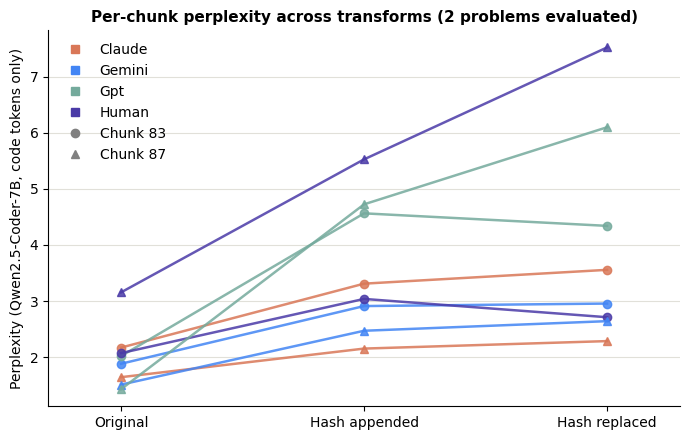

In [16]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 4.5))
transform_x = {t: i for i, t in enumerate(TRANSFORM_ORDER)}
CHUNK_MARKERS = {83: "o", 87: "^"}  # distinct marker per chunk_id
seen_sources: set[str] = set()
seen_chunks: set[int] = set()

for chunk_id, g in phase1.groupby("chunk_id"):
    chunk_num = int(chunk_id.split(":")[0])
    g = g.set_index("transform").reindex(TRANSFORM_ORDER)
    source = g["source"].iloc[0]
    marker = CHUNK_MARKERS.get(chunk_num, "x")  # fallback if unexpected chunk_id
    ax.plot(
        [transform_x[t] for t in TRANSFORM_ORDER], g["perplexity_raw"].values,
        color=BRAND_COLORS[source], marker=marker, markersize=6, linewidth=1.8,
        alpha=0.85,
    )
    seen_sources.add(source)
    seen_chunks.add(chunk_num)

ax.set_xticks(list(transform_x.values()))
ax.set_xticklabels([TRANSFORM_LABELS[t] for t in TRANSFORM_ORDER])
ax.set_xlim(-0.3, len(TRANSFORM_ORDER) - 0.7)
ax.set_ylabel("Perplexity (Qwen2.5-Coder-7B, code tokens only)")
ax.set_title("Per-chunk perplexity across transforms (2 problems evaluated)", fontsize=11, fontweight="bold")
style_axes(ax)

# Build one combined set of legend handles: source (color) entries + chunk (marker) entries
source_handles = [
    Line2D([0], [0], color=BRAND_COLORS[s], marker="s", linestyle="", markersize=6, label=s.capitalize())
    for s in sorted(seen_sources)
]
chunk_handles = [
    Line2D([0], [0], color="gray", marker=CHUNK_MARKERS[c], linestyle="", markersize=6, label=f"Chunk {c}")
    for c in sorted(seen_chunks)
]

ax.legend(handles=source_handles + chunk_handles, frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

### Obfuscation and bug detection in self-generated code. 

Here's a chart showing bug detection rates by code transformation. There is no clear reversal of the self-preference trend with the transformations applied. 

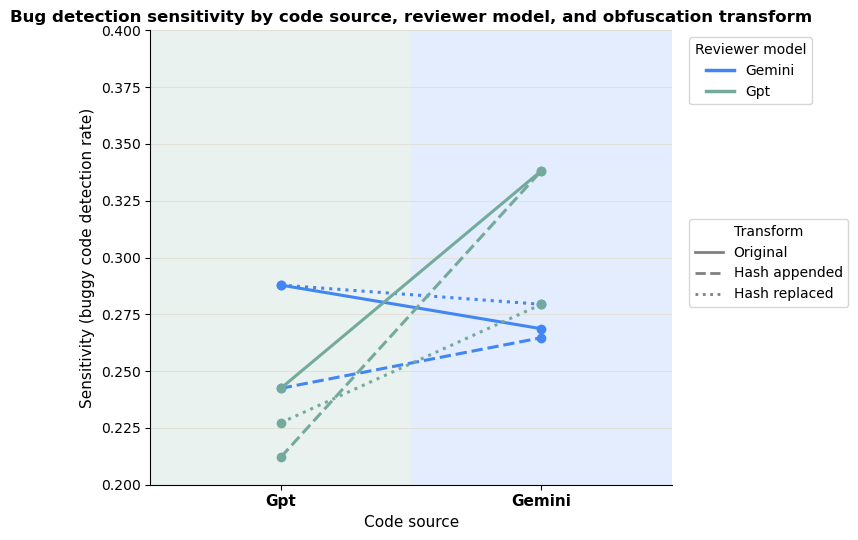

In [101]:
from matplotlib.lines import Line2D


def lighten(hex_color, amount=0.85):
    """Blend a hex color toward white. amount=0 -> no change, amount=1 -> white."""
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    r = r + (255 - r) * amount
    g = g + (255 - g) * amount
    b = b + (255 - b) * amount
    return (r / 255, g / 255, b / 255)


TRANSFORM_STYLES = {
    "original": "-",
    "hash_append": "--",
    "hash_replace": ":",
}

REVIEWER_ORDER = ["gemini", "gpt"]
SOURCE_ORDER = ["gpt", "gemini"]  # human excluded: too few human bugs (n=2) to be informative


def sensitivity_by_reviewer(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df["bug_detected"].notna()].copy()
    valid["bug_detected"] = valid["bug_detected"].astype(bool)
    valid = valid[~valid["is_correct"]]  # sensitivity = recall on buggy code only
    return (
        valid.groupby(["source", "reviewer_model", "transform"])
        .agg(rate=("bug_detected", "mean"), n=("bug_detected", "size"))
        .reset_index()
    )

sensitivity2 = sensitivity_by_reviewer(phase2)

x_pos = {s: i for i, s in enumerate(SOURCE_ORDER)}

fig, ax = plt.subplots(figsize=(8, 5.5))

# Light background band per source column (same brand colors as elsewhere in the post)
for s in SOURCE_ORDER:
    ax.axvspan(x_pos[s] - 0.5, x_pos[s] + 0.5, color=lighten(BRAND_COLORS[s]), zorder=0)

# One line per reviewer_model x transform
for reviewer in REVIEWER_ORDER:
    for transform, ls in TRANSFORM_STYLES.items():
        sub = (
            sensitivity2[(sensitivity2["reviewer_model"] == reviewer) & (sensitivity2["transform"] == transform)]
            .set_index("source")
            .reindex(SOURCE_ORDER)
        )
        ax.plot(
            [x_pos[s] for s in SOURCE_ORDER],
            sub["rate"].values,
            color=BRAND_COLORS[reviewer],
            linestyle=ls,
            marker="o",
            markersize=6,
            linewidth=2.2,
            zorder=3,
        )

ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([s.capitalize() for s in SOURCE_ORDER], fontsize=11, fontweight="bold")
ax.set_xlim(-0.5, len(SOURCE_ORDER) - 0.5)
ax.set_ylim(0.2, 0.4)
ax.set_ylabel("Sensitivity (buggy code detection rate)", fontsize=11)
ax.set_xlabel("Code source", fontsize=11)
ax.set_title("Bug detection sensitivity by code source, reviewer model, and obfuscation transform", fontsize=12, fontweight="bold")
style_axes(ax)

model_handles = [Line2D([0], [0], color=BRAND_COLORS[m], lw=2.5, label=m.capitalize()) for m in REVIEWER_ORDER]
transform_handles = [
    Line2D([0], [0], color="gray", lw=2, linestyle=ls, label=TRANSFORM_LABELS[t])
    for t, ls in TRANSFORM_STYLES.items()
]

legend1 = ax.legend(handles=model_handles, title="Reviewer model", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.legend(handles=transform_handles, title="Transform", loc="upper left", bbox_to_anchor=(1.02, 0.6))
ax.add_artist(legend1)

fig.tight_layout()
plt.show()


Here are some logistic regression outputs confirming the results. Neither transformation had a significant interaction with variable concordance, so we don't have evidence to believe that this transformation is useful.

In [102]:
import statsmodels.formula.api as smf


def fit_obfuscation_logit(df: pd.DataFrame, buggy: bool):
    valid = df[df["bug_detected"].notna()].copy()
    valid["bug_detected"] = valid["bug_detected"].astype(int)
    valid = valid[valid["source"].isin(SOURCE_ORDER)]
    valid = valid[~valid["is_correct"] if buggy else valid["is_correct"]]
    valid['concordant_model'] = (valid['source'] == valid['reviewer_model']).astype(int)
    return smf.logit(
        "bug_detected ~ C(transform, Treatment('original'))*concordant_model + C(source) + C(reviewer_model)",
        data=valid,
    ).fit(cov_type="cluster", cov_kwds={"groups": valid["problem_id"]}, disp=False)


def odds_ratio_table(model) -> pd.DataFrame:
    conf = model.conf_int()
    conf.columns = ["ci_low", "ci_high"]
    return pd.DataFrame({
        "odds_ratio": np.exp(model.params),
        "ci_low": np.exp(conf["ci_low"]),
        "ci_high": np.exp(conf["ci_high"]),
        "p_value": model.pvalues,
    }).round(3)


sensitivity_model = fit_obfuscation_logit(phase2, buggy=True)
odds_ratio_table(sensitivity_model)


,odds_ratio,ci_low,ci_high,p_value
Intercept,0.511,0.309,0.847,0.009
"C(transform, Treatment('original'))[T.hash_append]",0.899,0.728,1.109,0.321
"C(transform, Treatment('original'))[T.hash_replace]",0.867,0.676,1.111,0.258
C(source)[T.gpt],0.797,0.491,1.293,0.357
C(reviewer_model)[T.gpt],0.993,0.664,1.486,0.974
concordant_model,0.752,0.556,1.016,0.064
"C(transform, Treatment('original'))[T.hash_append]:concordant_model",1.015,0.723,1.425,0.931
"C(transform, Treatment('original'))[T.hash_replace]:concordant_model",1.141,0.803,1.622,0.461


## A more useful framing: does the reviewer model "understand" the concepts involved in a given problem?

Given the results above, I don't think that a perplexity-derived self-preference effect is the main limiting factor for automated code review. While doing manual review of coding failures, I didn't find that many instances of a generator LLM not "understanding" what the code was doing, but I did find cases where the generator LLM did not have a sufficient understanding of concepts involved to solve the problem. For example, one problem asked LLMs to identify [undulating numbers](https://en.wikipedia.org/wiki/Undulating_number) and both LLM generators created a function that identified *non-trivial undulating numbers*, which makes sense given that these models are likely distilled from larger models, and the difference between trivial and non-trivial undulating numbers was probably not sufficiently important to make it through the distillation process. 

In my experiments on LLM-enabled bug detection, there was a clear pattern where a model's bug-detection capabilities were much higher on problems that it solved correctly itself. So, if a model "understood" some concept well enough to generate correct code in the first place, it was likely to identify errors in code attempting to solve the same problem. Note that this isn't really a clean experiment (yep, still trying to talk myself into buying a GPU, and I'll need a few of those to run a clean experiment there) but it does make intuitive sense. 

In [23]:
results = pd.read_csv(RESULTS_DIR / "results.csv")
results = results[results["reviewer_persona"] == "persona_1"].copy()
results = results[results["bug_detected"].notna()].copy()
results["bug_detected"] = results["bug_detected"].astype(bool)
results["is_correct"] = results["successful_run_pre_review"].astype(bool)

# "Understood" = did this reviewer model, acting as generator, solve this problem itself.
own_understanding = (
    results[results["generator_model"] == results["reviewer_model"]]
    [["reviewer_model", "problem_id", "successful_run_pre_review"]]
    .drop_duplicates()
    .rename(columns={"successful_run_pre_review": "reviewer_understood"})
)
results = results.merge(own_understanding, on=["reviewer_model", "problem_id"], how="left")


def understanding_rates(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    for key, g in df.groupby(group_cols):
        key = key if isinstance(key, tuple) else (key,)
        buggy, correct = g[~g["is_correct"]], g[g["is_correct"]]
        rows.append({
            **dict(zip(group_cols, key)),
            "sensitivity": buggy["bug_detected"].mean() if len(buggy) else float("nan"),
            "n_buggy": len(buggy),
            "false_positive_rate": correct["bug_detected"].mean() if len(correct) else float("nan"),
            "n_correct": len(correct),
        })
    return pd.DataFrame(rows)


UNDERSTOOD_COLORS = {True: "#2a78d6", False: "#898781"}
UNDERSTOOD_LABELS = {True: "Reviewer solved this problem itself", False: "Reviewer failed this problem itself"}

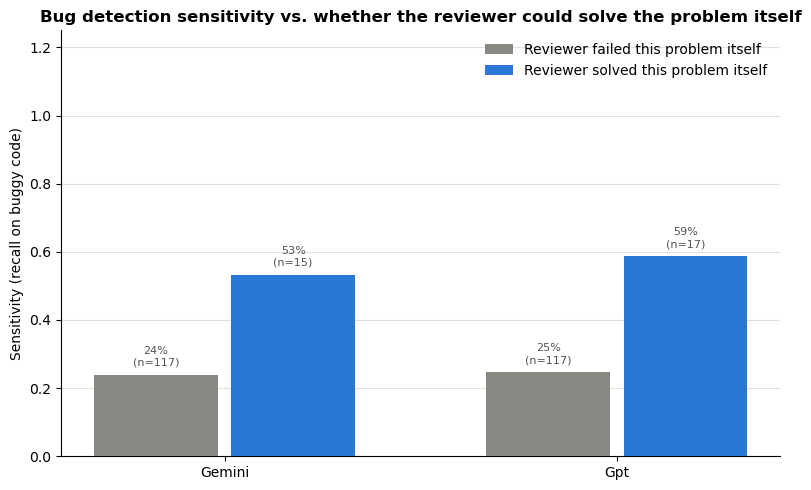

In [25]:
by_model = understanding_rates(results, ["reviewer_model", "reviewer_understood"])
reviewer_order4 = [ "gemini", "gpt"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(reviewer_order4))
bar_width = 0.35
for i, understood in enumerate([False, True]):
    offset = (i - 0.5) * bar_width
    sub = by_model[by_model["reviewer_understood"] == understood].set_index("reviewer_model").reindex(reviewer_order4)
    bars = ax.bar(x + offset, sub["sensitivity"].values, width=bar_width * 0.9,
                   color=UNDERSTOOD_COLORS[understood],
                   label=UNDERSTOOD_LABELS[understood], zorder=3)
    for bar, val, n in zip(bars, sub["sensitivity"].values, sub["n_buggy"].values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}\n(n={n:.0f})",
                     ha="center", va="bottom", fontsize=8, color="#52514e")

ax.set_xticks(x)
ax.set_xticklabels([r.capitalize() for r in reviewer_order4])
ax.set_ylim(0, 1.25)
ax.set_ylabel("Sensitivity (recall on buggy code)")
ax.set_title("Bug detection sensitivity vs. whether the reviewer could solve the problem itself", fontsize=12, fontweight="bold")
style_axes(ax)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

To conclude, I'll share some somewhat relevant ideas for good performance on LLM-assisted coding. 
1. Have a stronger model make a plan for exactly waht to do, including edge cases for unit tests. This can be done in relatively few turns, requiring less token usage overall. The stronger model can include relevant details (like considerations on non-trivial undulating numbers) to the weaker model if needed. 
2. Have a weaker model implement the code as well as the tests (this may take relatively more turns to get everything working correctly)
3. Have a stronger model review the weaker model's outputs